In [34]:
import matplotlib.pyplot as plt
import librosa
import numpy as np
from IPython.display import Audio, display

import ruptures as rpt  # our packageimport matplotlib.pyplot as plt
from scipy.stats import zscore
from ruptures.base import BaseCost
from scipy.ndimage import gaussian_filter1d


In [2]:
def fig_ax(figsize=(15, 5), dpi=150):
    """Return a (matplotlib) figure and ax objects with given size."""
    return plt.subplots(figsize=figsize, dpi=dpi)


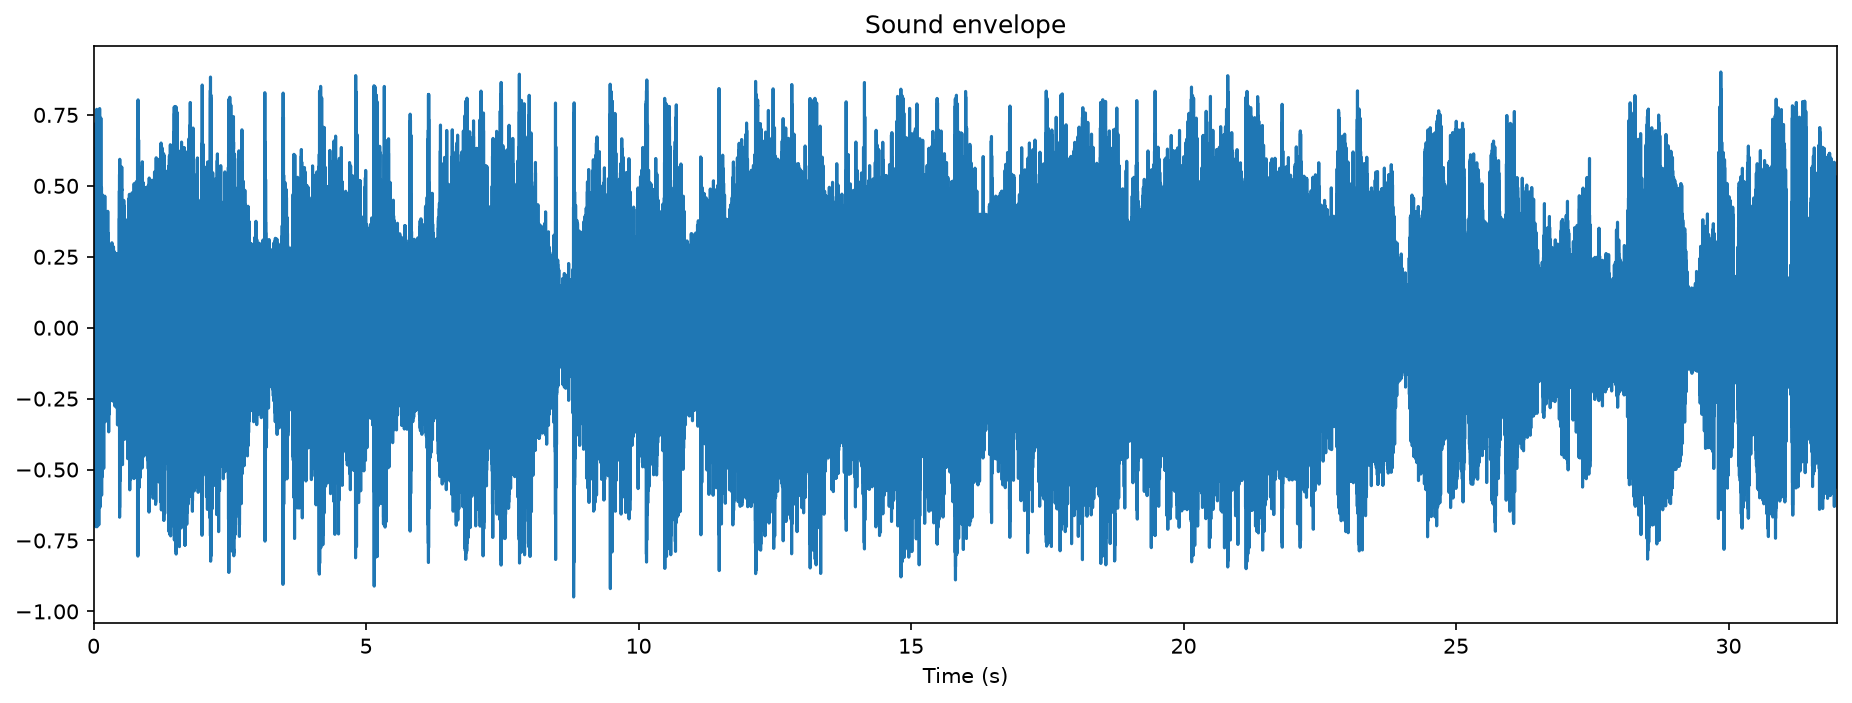

In [261]:
duration = 32  # in seconds
sr = 22050
hop_length = 2048
# True bkpt 10s both harmonic and drop-in
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Bollywood 2010's/2026-09-15_21-18-24.mp3", sr=sr)
# True bkpt 2, harmonic at 16s
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Bollywood 2010's/2026-09-15_21-22-08.mp3", sr=sr)
# Strong breakpoint at 11s not harmonic
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-15_21-17-40.mp3", sr=sr)
# breakpoint at 11s end
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-15_21-22-08.mp3", sr=sr)
# No breaks example
y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-15_21-18-24.mp3", sr=sr)

# listen to the music
display(Audio(data=y, rate=sr))

# look at the envelope
fig, ax = fig_ax()
ax.plot(np.arange(y.size) / sr, y)
ax.set_xlim(0, y.size / sr)
ax.set_xlabel("Time (s)")
_ = ax.set(title="Sound envelope")


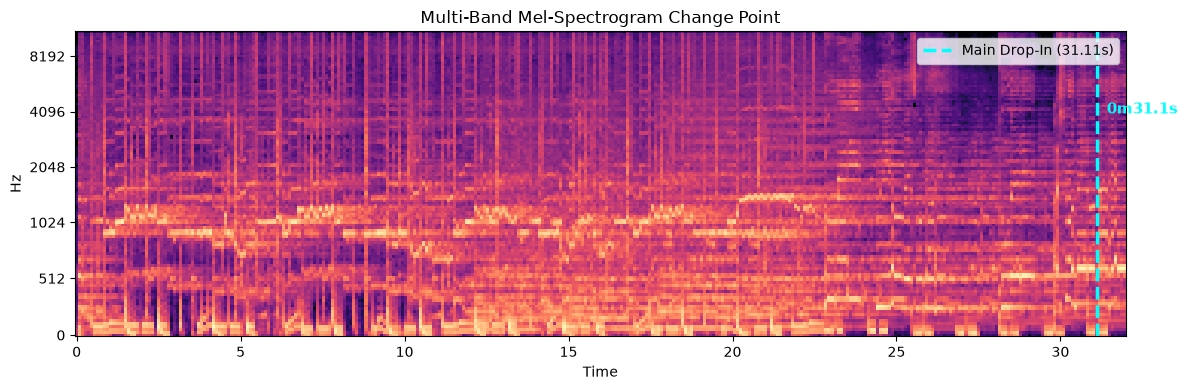

In [262]:
# ==========================================
# 2. Extract Multi-Band Log-Mel Features
# ==========================================
# 16 Mel bands capture bass, mids, and high-frequency energy shifts independently
S = librosa.feature.melspectrogram(
    y=y, sr=sr, n_mels=16, hop_length=hop_length
)
S_dB = librosa.power_to_db(S, ref=np.max)

# Transpose for ruptures: shape becomes (n_frames, 16_mel_bands)
features = zscore(S_dB, axis=1).T

# ==========================================
# 3. Window Search across Frequency Bands
# ==========================================
# 3-second sliding window evaluates spectral density state changes
window_sec = 3.0
width_frames = int((window_sec * sr) / hop_length)

algo = rpt.Window(model="rbf", width=width_frames, jump=2).fit(features)

# Request the single dominant macro change point (n_bkps=1)
predicted_frames = algo.predict(pen=25)

if len(predicted_frames) == 0:
    cut_timestamps = []
    print("No breakpoints detected.")
    exit()

# Backtrack to the exact transient attack frame
onset_frames = librosa.onset.onset_detect(
    y=y, sr=sr, hop_length=hop_length, backtrack=True, units="frames"
)

raw_frame = predicted_frames[0]
valid_onsets = onset_frames[onset_frames <= raw_frame + 10]
exact_frame = valid_onsets[-1] if len(valid_onsets) > 0 else raw_frame

exact_time = librosa.frames_to_time(exact_frame, sr=sr, hop_length=hop_length)

# ==========================================
# 4. Plot Result over Spectrogram
# ==========================================
fig, ax = plt.subplots(figsize=(12, 4))
S_full = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y, sr=sr, hop_length=hop_length),
    ref=np.max,
)
img = librosa.display.specshow(
    S_full,
    y_axis="mel",
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
    ax=ax,
    cmap="magma",
)

mins, secs = divmod(exact_time, 60)
ax.axvline(
    x=exact_time,
    color="cyan",
    linestyle="--",
    linewidth=2.5,
    label=f"Main Drop-In ({exact_time:.2f}s)",
)
ax.text(
    exact_time + 0.3,
    4000,
    f"{int(mins)}m{secs:04.1f}s",
    color="cyan",
    fontweight="bold",
    fontsize=11,
)

ax.set_title("Multi-Band Mel-Spectrogram Change Point", fontsize=12)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(Audio(y, rate=sr))

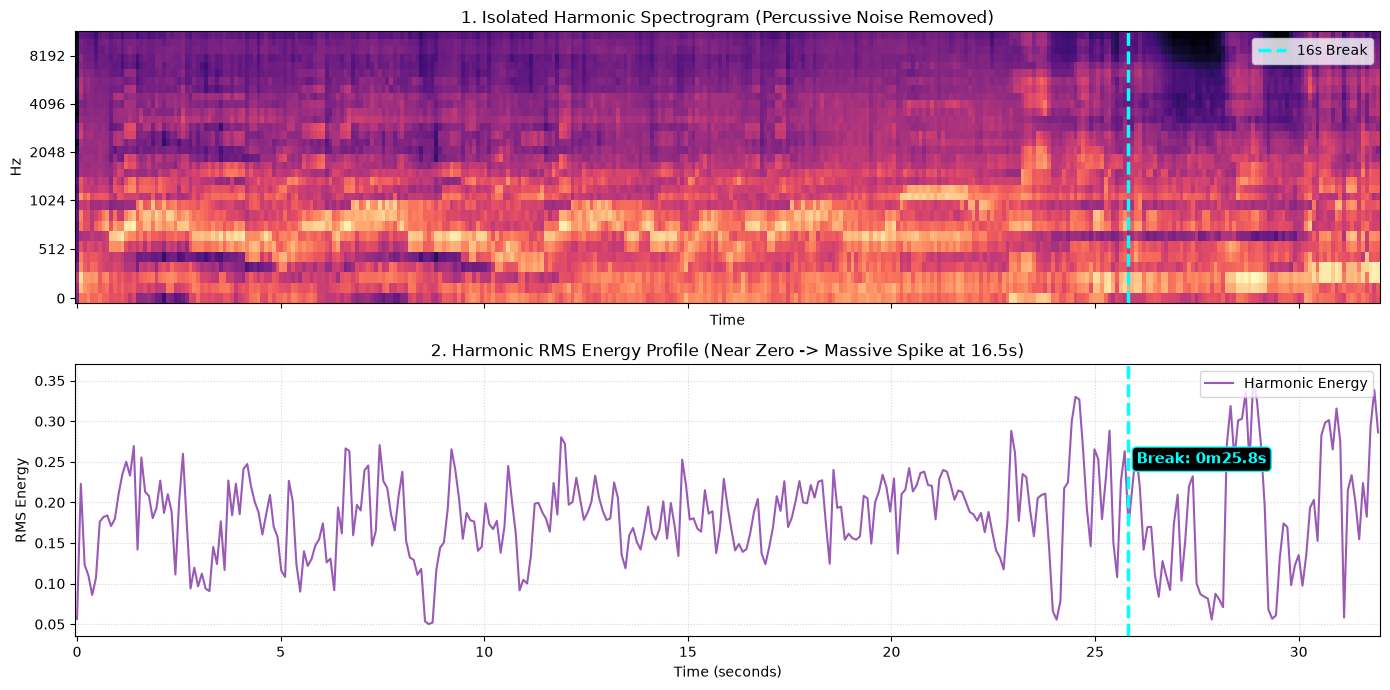

In [ ]:
# HPSS: Extract purely harmonic audio (synths, vocals, chords)
# Ignores drum hits and broad-band noise sweeps
y_harmonic, _ = librosa.effects.hpss(y)

# ==========================================
# 2. Extract Harmonic Mel Spectrogram
# ==========================================
# Focus on mid/high frequencies (fmin=300Hz) where synth chords reside
S_harm = librosa.feature.melspectrogram(
    y=y_harmonic, sr=sr, n_mels=32, fmin=300, hop_length=hop_length
)
S_harm_dB = librosa.power_to_db(S_harm, ref=np.max)

# Feature matrix for ruptures
features = zscore(S_harm_dB, axis=1).T

# ==========================================
# 3. Ruptures Window Search (Targeting 1 Breakpoint)
# ==========================================
window_sec = 2.5
width_frames = int((window_sec * sr) / hop_length)

# On y_harmonic, the 16.5s synth drop produces the single LARGEST cost jump
algo = rpt.Window(model="l2", width=width_frames, jump=2).fit(features)
raw_frame = algo.predict(n_bkps=1)[0]

# Backtrack to exact transient attack
onset_frames = librosa.onset.onset_detect(
    y=y, sr=sr, hop_length=hop_length, backtrack=True, units="frames"
)
valid_onsets = onset_frames[
    (onset_frames <= raw_frame + 10) & (onset_frames >= raw_frame - 20)
]
exact_frame = valid_onsets[-1] if len(valid_onsets) > 0 else raw_frame

exact_time = librosa.frames_to_time(exact_frame, sr=sr, hop_length=hop_length)

# ==========================================
# 4. Dual-Chart Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# TOP PANEL: Harmonic Spectrogram
librosa.display.specshow(
    S_harm_dB,
    y_axis="mel",
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
    ax=ax1,
    cmap="magma",
)
ax1.axvline(
    x=exact_time, color="cyan", linestyle="--", linewidth=2.5, label="16s Break"
)
ax1.set_title(
    "1. Isolated Harmonic Spectrogram (Percussive Noise Removed)", fontsize=12
)
ax1.legend(loc="upper right")

# BOTTOM PANEL: Harmonic Energy Profile
harmonic_rms = librosa.feature.rms(
    y=y_harmonic, frame_length=2048, hop_length=hop_length
)[0]
times = librosa.times_like(harmonic_rms, sr=sr, hop_length=hop_length)

ax2.plot(times, harmonic_rms, color="#9b59b6", linewidth=1.5, label="Harmonic Energy")
ax2.axvline(x=exact_time, color="cyan", linestyle="--", linewidth=2.5)

mins, secs = divmod(exact_time, 60)
ax2.text(
    exact_time + 0.2,
    max(harmonic_rms) * 0.7,
    f"Break: {int(mins)}m{secs:04.1f}s",
    color="cyan",
    fontweight="bold",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="cyan", lw=1),
)

ax2.set_title("2. Harmonic RMS Energy Profile (Near Zero -> Massive Spike at 16.5s)", fontsize=12)
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("RMS Energy")
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

display(Audio(y, rate=sr))

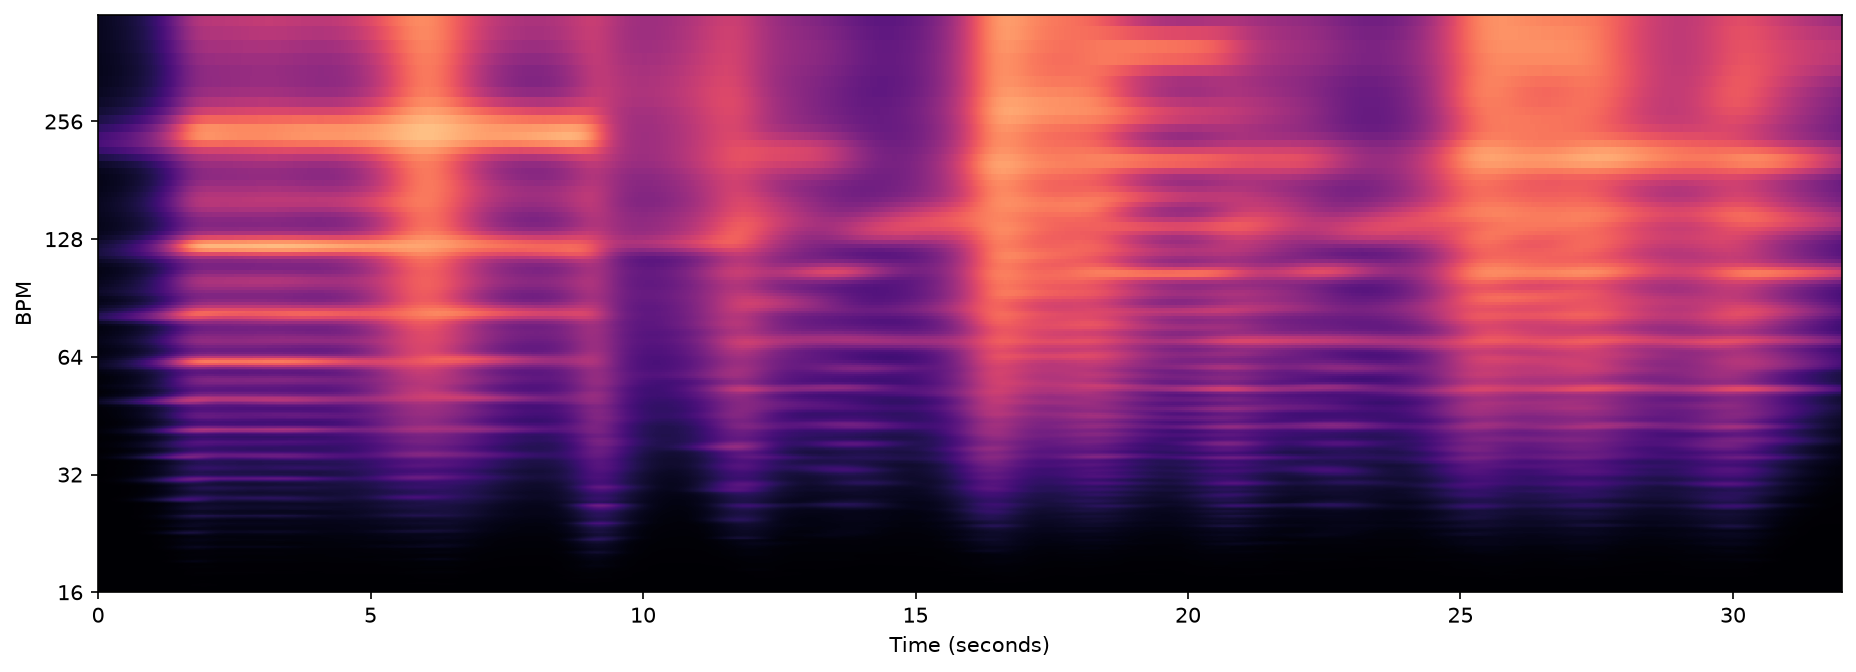

In [5]:
# Compute the onset strength
# hop_length_tempo = 256
hop_length_tempo = 256

oenv = librosa.onset.onset_strength(
    y=signal, sr=sampling_rate, hop_length=hop_length_tempo
)
# Compute the tempogram
tempogram = librosa.feature.tempogram(
    onset_envelope=oenv,
    sr=sampling_rate,
    hop_length=hop_length_tempo,
)
# Display the tempogram
fig, ax = fig_ax()
_ = librosa.display.specshow(
    tempogram,
    ax=ax,
    hop_length=hop_length_tempo,
    sr=sampling_rate,
    x_axis="s",
    y_axis="tempo",
)


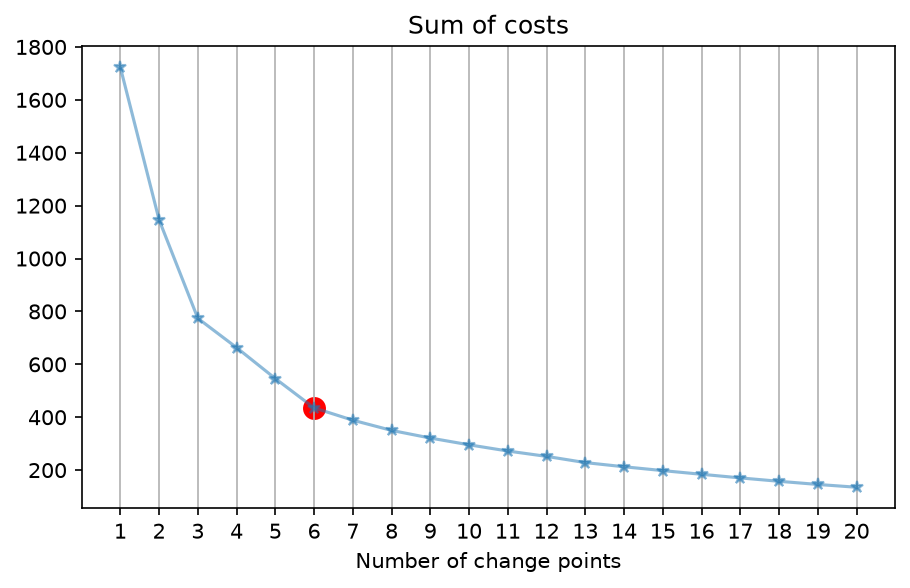

In [20]:
# Choose detection method
min_segment_sec = 30
min_frames = int((min_segment_sec * sampling_rate) / hop_length_tempo) 
algo = rpt.KernelCPD(kernel="linear").fit(tempogram.T)
# algo = rpt.KernelCPD(kernel="linear").fit(beat_mfcc_delta.T)

# Choose the number of changes (elbow heuristic)
n_bkps_max = 20  # K_max
# Start by computing the segmentation with most changes.
# After start, all segmentations with 1, 2,..., K_max-1 changes are also available for free.
_ = algo.predict(n_bkps_max)

array_of_n_bkps = np.arange(1, n_bkps_max + 1)


def get_sum_of_cost(algo, n_bkps) -> float:
    """Return the sum of costs for the change points `bkps`"""
    bkps = algo.predict(n_bkps=n_bkps)
    return algo.cost.sum_of_costs(bkps)


fig, ax = fig_ax((7, 4))
ax.plot(
    array_of_n_bkps,
    [get_sum_of_cost(algo=algo, n_bkps=n_bkps) for n_bkps in array_of_n_bkps],
    "-*",
    alpha=0.5,
)
ax.set_xticks(array_of_n_bkps)
ax.set_xlabel("Number of change points")
ax.set_title("Sum of costs")
ax.grid(axis="x")
ax.set_xlim(0, n_bkps_max + 1)

# Visually we choose n_bkps=5 (highlighted in red on the elbow plot)
n_bkps = 6
_ = ax.scatter([6], [get_sum_of_cost(algo=algo, n_bkps=6)], color="r", s=100)

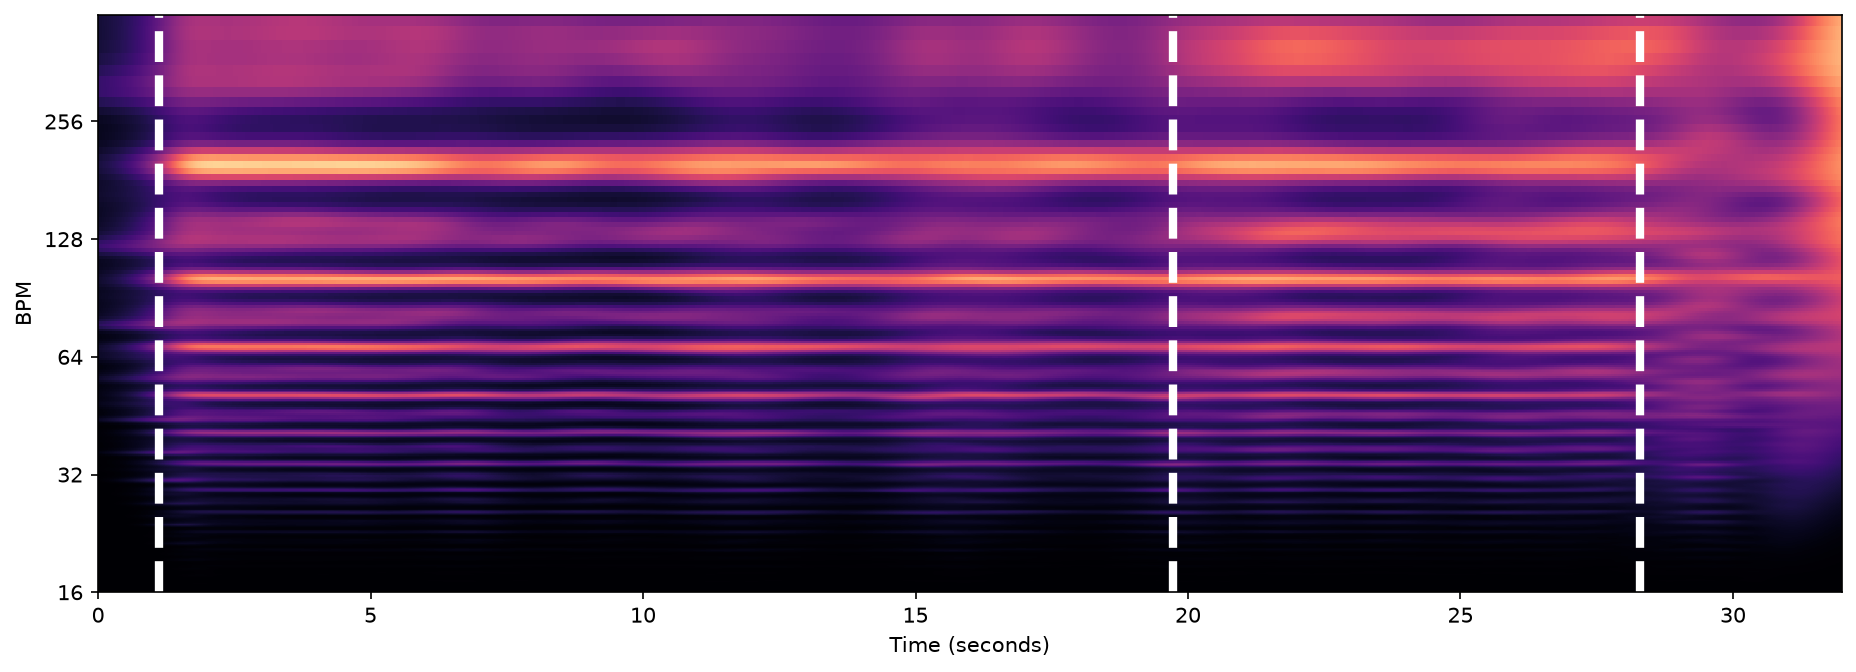

In [27]:
# Segmentation
# bkps = algo.predict(n_bkps=n_bkps)
bkps = algo.predict(pen=250)
# Convert the estimated change points (frame counts) to actual timestamps
bkps_times = librosa.frames_to_time(bkps, sr=sampling_rate, hop_length=hop_length_tempo)

# Displaying results
fig, ax = fig_ax()
_ = librosa.display.specshow(
    tempogram,
    ax=ax,
    x_axis="s",
    y_axis="tempo",
    hop_length=hop_length_tempo,
    sr=sampling_rate,
)

for b in bkps_times[:-1]:
    ax.axvline(b, ls="--", color="white", lw=4)


In [28]:
# Compute change points corresponding indexes in original signal
bkps_time_indexes = (sampling_rate * bkps_times).astype(int).tolist()

for segment_number, (start, end) in enumerate(
    rpt.utils.pairwise([0] + bkps_time_indexes), start=1
):
    segment = signal[start:end]
    print(f"Segment n°{segment_number} (duration: {segment.size/sampling_rate:.2f} s)")
    display(Audio(data=segment, rate=sampling_rate))


Segment n°1 (duration: 1.11 s)


Segment n°2 (duration: 18.61 s)


Segment n°3 (duration: 8.57 s)


Segment n°4 (duration: 3.70 s)
